<a href="https://colab.research.google.com/github/Nyevuu2/Mkulima-Smart/blob/main/Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Maize Model... Respecting modern price trends...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.2487 - val_loss: 0.8279
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0487 - val_loss: 0.3300
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0409 - val_loss: 0.6111
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0356 - val_loss: 0.4837
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0325 - val_loss: 0.4163
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0313 - val_loss: 0.3940
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0291 - val_loss: 0.4014
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0312 - val_loss: 0.3516
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0269 - val_loss: 0.3453



✅ Success! Downloading maize_price_model_weighted.h5...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

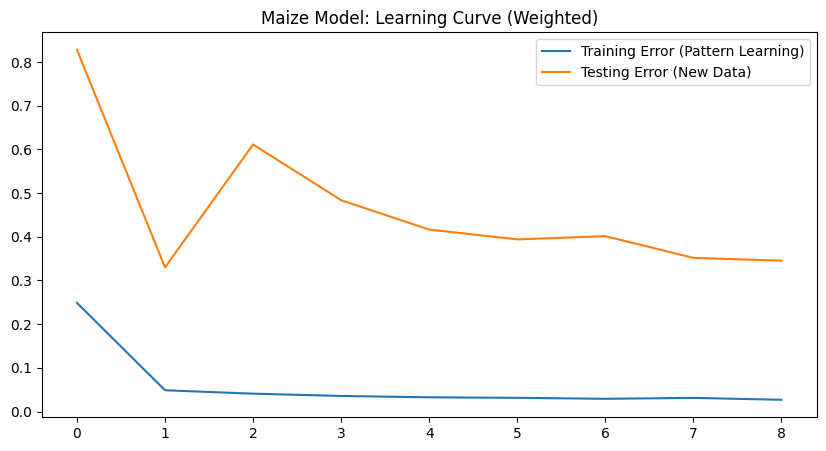

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import files

# 1. LOAD DATA
# Ensure 'Maize_cleaned_master.csv' is in your Colab sidebar
df = pd.read_csv('Maize_cleaned_master.csv', index_col='Date', parse_dates=True)

# 2. DATA CLEANING (The "Reasonable" Fix)
# We remove any wholesale prices above 130 KES to clean the "typo" spikes
df = df[df['Wholesale'] < 130]

# 3. SPLIT DATA (80/20)
train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

# 4. SCALE DATA
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data[['Wholesale']])
test_scaled = scaler.transform(test_data[['Wholesale']])

# 5. CREATE SEQUENCES (12-month lookback)
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

# 6. ASSIGN WEIGHTS (The "Inflation" Fix)
# We give the most recent 5 years of training data 5x more priority
weights = np.ones(len(y_train))
weights[-60:] = 5.0

# 7. BUILD THE LSTM ARCHITECTURE
model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(12, 1)),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

# 8. TRAIN WITH EARLY STOPPING
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("Training Maize Model... Respecting modern price trends...")
history = model.fit(
    X_train, y_train,
    sample_weight=weights,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 9. SAVE & DOWNLOAD
model_name = 'maize_price_model_weighted.h5'
model.save(model_name)
print(f"\n✅ Success! Downloading {model_name}...")
files.download(model_name)

# 10. VISUALIZE LEARNING
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Error (Pattern Learning)')
plt.plot(history.history['val_loss'], label='Testing Error (New Data)')
plt.title('Maize Model: Learning Curve (Weighted)')
plt.legend()
plt.show()

Training Ndengu Model... Learning modern Green Gram trends...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.7490 - val_loss: 0.1878
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0910 - val_loss: 0.0357
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0627 - val_loss: 0.0439
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0509 - val_loss: 0.0523
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0471 - val_loss: 0.0385
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0434 - val_loss: 0.0390
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0501 - val_loss: 0.0432
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0390 - val_loss: 0.0405
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0432 - val_loss: 0.0394



✅ Ndengu Model Saved! Downloading ndengu_price_model_weighted.h5...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

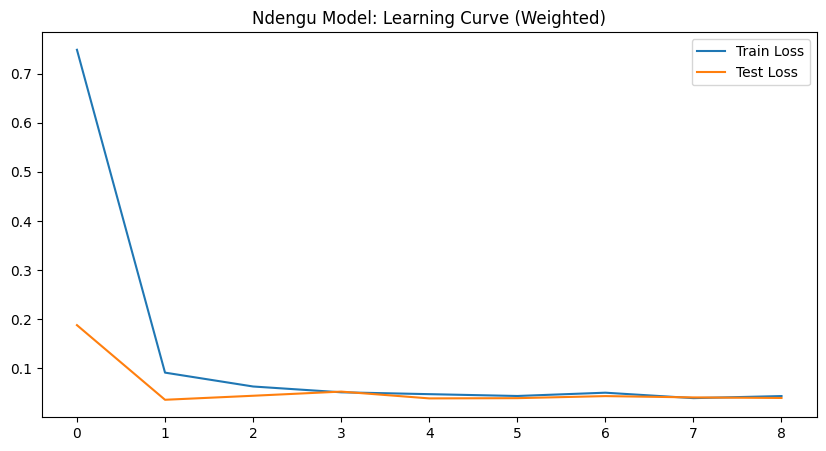

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import files

# 1. LOAD DATA
# Ensure 'Ndengu_cleaned_master.csv' is uploaded to your Colab sidebar
df_n = pd.read_csv('Ndengu_cleaned_master.csv', index_col='Date', parse_dates=True)

# 2. DATA CLEANING
# Removing wholesale prices above 180 KES/kg to clean up data entry errors
df_n = df_n[df_n['Wholesale'] < 180]

# 3. SPLIT DATA (80% Train, 20% Test)
train_size_n = int(len(df_n) * 0.8)
train_n = df_n.iloc[:train_size_n]
test_n = df_n.iloc[train_size_n:]

# 4. SCALE DATA
scaler_n = MinMaxScaler()
train_n_scaled = scaler_n.fit_transform(train_n[['Wholesale']])
test_n_scaled = scaler_n.transform(test_n[['Wholesale']])

# 5. CREATE SEQUENCES (12-month lookback)
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train_n, y_train_n = create_sequences(train_n_scaled)
X_test_n, y_test_n = create_sequences(test_n_scaled)

# 6. ASSIGN WEIGHTS (Modern Price Priority)
# Giving the last 60 months (5 years) 5x more importance for the LSTM
weights_n = np.ones(len(y_train_n))
weights_n[-60:] = 5.0

# 7. BUILD THE NDENGU LSTM
model_n = Sequential([
    LSTM(32, return_sequences=True, input_shape=(12, 1)),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.2),
    Dense(1)
])
model_n.compile(optimizer='adam', loss='mean_squared_error')

# 8. TRAIN WITH EARLY STOPPING
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print("Training Ndengu Model... Learning modern Green Gram trends...")
history_n = model_n.fit(
    X_train_n, y_train_n,
    sample_weight=weights_n,
    epochs=100,
    batch_size=16,
    validation_data=(X_test_n, y_test_n),
    callbacks=[early_stop],
    verbose=1
)

# 9. SAVE & DOWNLOAD
model_path = 'ndengu_price_model_weighted.h5'
model_n.save(model_path)
print(f"\n✅ Ndengu Model Saved! Downloading {model_path}...")
files.download(model_path)

# 10. VISUALIZE
plt.figure(figsize=(10, 5))
plt.plot(history_n.history['loss'], label='Train Loss')
plt.plot(history_n.history['val_loss'], label='Test Loss')
plt.title('Ndengu Model: Learning Curve (Weighted)')
plt.legend()
plt.show()